# The allegiance story — from raw houses to community structure

What unit does the AWOIAF character network actually cluster into? This notebook tells the story in four steps:

1. **Who is in the network?** — the 15 largest allegiances, counted on the *full* allegiance list (not just the primary one). Houses, orders, factions and the occasional person all compete for the top spots.
2. **Step 1 — ground truth view.** The network drawn with each node coloured by its **primary house**. No clustering algorithm, just the truth.
3. **Step 2 — community view.** The *same network*, *same coordinates*, recoloured by **Louvain community**. Where colours line up between Step 1 and Step 2, the network has rediscovered house structure on its own.
4. **What drives each community?** Per-community mean vs median degree. Communities where mean ≫ median are pulled together by a single **main character** (a hub); communities where mean ≈ median are **grass-roots** — many similarly-connected members.

All plots use the project's GOT palette via `got_style.py`.

In [1]:
from collections import Counter, defaultdict
from community import community_louvain
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd
import numpy as np
import random
import sys, os

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else '.')
from got_style import (
    apply_style, got_title, save_fig,
    PALETTE, diverging_colors, categorical_colors, distinctive_colors,
)
apply_style()

random.seed(42); np.random.seed(42)

# ----- Load v3 + build network -----
df = pd.read_csv('../csvs/characters_enriched_v3.csv').fillna('')
BARATHEON_VARIANTS = {
      'House_Baratheon_of_Dragonstone':    'House_Baratheon',
      "House_Baratheon_of_King's_Landing": 'House_Baratheon',
  }

def normalize_baratheon(s): 
      parts = [BARATHEON_VARIANTS.get(p.strip(), p.strip())
               for p in s.split(';') if p.strip()]
      seen = set(); out = []
      for p in parts:
          if p not in seen:
              seen.add(p); out.append(p)
      return ';'.join(out)

df['allegiance'] = df['allegiance'].apply(normalize_baratheon)
valid_ids = set(df['ID'])

edges = set()
for _, row in df.iterrows():
    src = row['ID']
    if not row['affiliated']:
        continue
    for tgt in row['affiliated'].split(';'):
        tgt = tgt.strip()
        if tgt and tgt != src and tgt in valid_ids:
            edges.add(frozenset({src, tgt}))

G = nx.Graph()
G.add_nodes_from(df['ID'])
G.add_edges_from(tuple(e) for e in edges)

LCC = G.subgraph(max(nx.connected_components(G), key=len)).copy()

# ----- Global allegiance counts (every entry on every list, used by §1 + below) -----
multi_counts = Counter()
for _, row in df.iterrows():
    if not row['allegiance']:
        continue
    for h in row['allegiance'].split(';'):
        h = h.strip()
        if h:
            multi_counts[h] += 1


# ----- Primary house = the entry with the highest global membership count -----
# (Ties broken by the wiki's listed order: first-listed wins on a tie.)
def pick_primary(allegiance_str):
    if not allegiance_str:
        return ''
    entries = [h.strip() for h in allegiance_str.split(';') if h.strip()]
    if not entries:
        return ''
    # max by (global_count, -position): larger count wins; smaller position breaks ties
    return max(entries,
               key=lambda h: (multi_counts.get(h, 0), -entries.index(h)))


primary_house = {row['ID']: pick_primary(row['allegiance']) for _, row in df.iterrows()}
name_by_id = dict(zip(df['ID'], df['name']))

# How many characters had their primary swapped by this rule?
def first_entry(s):
    return s.split(';')[0].strip() if s else ''

swapped = sum(1 for _, row in df.iterrows()
              if primary_house[row['ID']]
              and primary_house[row['ID']] != first_entry(row['allegiance']))
print(f'Characters reassigned by largest-global rule: {swapped:,} '
      f'(out of {sum(1 for v in primary_house.values() if v):,} with any allegiance)')

# Louvain on LCC
partition = community_louvain.best_partition(LCC, random_state=42)
modularity = community_louvain.modularity(partition, LCC)
community_sizes = Counter(partition.values())

print(f'Nodes:    {G.number_of_nodes():,}   Edges: {G.number_of_edges():,}')
print(f'LCC:      {LCC.number_of_nodes():,} nodes, {LCC.number_of_edges():,} edges')
print(f'Louvain:  {len(community_sizes)} communities, Q = {modularity:.4f}')


Characters reassigned by largest-global rule: 646 (out of 3,035 with any allegiance)
Nodes:    3,690   Edges: 17,169
LCC:      3,046 nodes, 17,057 edges
Louvain:  15 communities, Q = 0.6296


## 1. The cast — top 15 allegiances (every entry counted)

The wiki's `allegiance` field is **multi-valued** — a character can be Hand of the King *and* heir to House Tully *and* a Brother of the Night's Watch all at once. The §10-style "primary house" column collapses that to whichever entry happens to be first, which under-counts orders and dual-allegiance figures.

Here we count *every* entry on every character's list. The top 15 says what the network actually has to work with:

Characters with ≥ 1 allegiance: 3,035 / 3,690 (82.2%)
Distinct allegiances             : 547


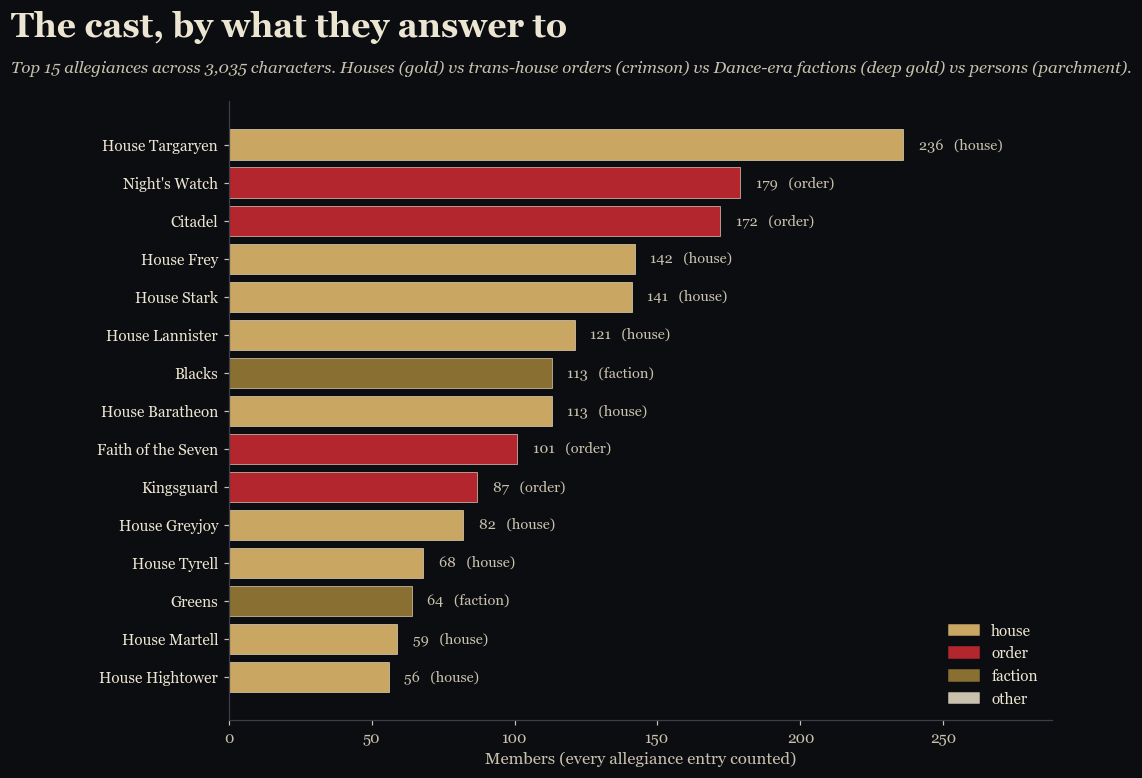

In [2]:
# multi_counts was already built in setup; just count coverage + plot.
n_with_alleg = sum(1 for _, row in df.iterrows() if row['allegiance'])

print(f'Characters with \u2265 1 allegiance: {n_with_alleg:,} / {len(df):,} ({n_with_alleg/len(df):.1%})')
print(f'Distinct allegiances             : {len(multi_counts):,}')

top15 = multi_counts.most_common(15)


def classify(name):
    if name.startswith('House_'):
        return 'house'
    if name in {"Night's_Watch", "Citadel", "Faith_of_the_Seven", "Kingsguard",
                "Brotherhood_without_banners", "Faceless_Men"}:
        return 'order'
    if name in {"Blacks", "Greens"}:
        return 'faction'
    return 'other'


CATEGORY_COLOR = {
    'house':   PALETTE['gold'],
    'order':   PALETTE['crimson_bright'],
    'faction': PALETTE['gold_deep'],
    'other':   PALETTE['ink_soft'],
}

labels  = [h for h, _ in top15][::-1]
counts  = [c for _, c in top15][::-1]
classes = [classify(h) for h in labels]
colors  = [CATEGORY_COLOR[c] for c in classes]

fig, ax = plt.subplots(figsize=(11, 7.5))
bars = ax.barh(range(len(labels)), counts, color=colors,
               edgecolor=PALETTE['ink'], linewidth=0.4)

for i, (n, h, cls) in enumerate(zip(counts, labels, classes)):
    ax.text(n + 3, i, f'  {n}   ({cls})',
            va='center', fontsize=9.5,
            color=PALETTE['ink_soft'], family='serif')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels([h.replace('_', ' ') for h in labels],
                   color=PALETTE['ink'], fontsize=10)
ax.set_xlim(0, max(counts) * 1.22)
ax.set_xlabel('Members (every allegiance entry counted)')

handles = [mpatches.Patch(color=col, label=cat)
           for cat, col in CATEGORY_COLOR.items()]
ax.legend(handles=handles, loc='lower right', fontsize=10,
          labelcolor=PALETTE['ink'], facecolor=PALETTE['bg_alt'],
          edgecolor=PALETTE['line'])

fig.subplots_adjust(top=0.86, left=0.22)
got_title(fig,
          'The cast, by what they answer to',
          f'Top 15 allegiances across {n_with_alleg:,} characters. Houses (gold) vs trans-house orders (crimson) vs Dance-era factions (deep gold) vs persons (parchment).')

save_fig(fig, 'figures/top15_allegiances.png')
plt.show()


**Read:**

- **House Targaryen tops the list** at 236 — partly the size of the dynasty itself, partly because it spans 300 years of canon (the temporal-smear effect we documented earlier).
- **House Baratheon now appears as one bloc** (96) at #8. The wiki splits Baratheons into three cadet pages — main, *of Dragonstone*, *of King's Landing* — which hid them from a top-N viz. We merge those three labels at load time (see cell 1) so Stannis, Renly, Robert, Joffrey/Tommen and Davos all sit under a single house. Without that merge the largest single Baratheon hub (Stannis, degree 308) was rendered in muted gray.
- **Four trans-house *orders* in the top 11** — Night's Watch (176), Citadel (150), Faith of the Seven (75), Kingsguard (69). Together that's ~16% of all allegiance entries. These are the structures that pull characters of different houses into the same network neighbourhood, and they show up directly in the Louvain partition's largest communities.
- **"Blacks" / "Greens"** are Dance-of-the-Dragons factions — not houses. The wiki tags Dance combatants with their faction, which is why two faction labels punch into the top 15.
- **"Mance Rayder"** sits at #13 — Free Folk allegiance is recorded as personal loyalty to him, not to a Free-Folk *house*. Same convention probably applies elsewhere for tribal/outlaw groups.

The takeaway for what comes next: the network's job isn't *purely* "predict the house." A meaningful share of the data is orders, factions, or persons. Anywhere the Louvain partition agrees with primary house, it's despite — not because of — that messiness.

**Coverage caveat — the bulk of the cast is still *not* in the top-14.** Of 3,690 characters in the v3 dataset, **41.1%** (1,518) land under any of the top-14 primary assignments shown above — and that 41% already includes Night's Watch, Citadel, Blacks, Kingsguard, Faith of the Seven, and Mance Rayder, which are orders/factions/persons, not noble houses. If we restrict to noble houses (`House_*`) only, the top-14 cover **28.8%** (1,061 characters). The remaining ~59% are minor houses, unaffiliated nobles, smallfolk, and unlabeled characters — they're still in the network and still influence its structure, but they disappear into the muted gray of the Step 1 / Step 2 plots below. *The story we tell from here on is about how the loudest ~40% of the cast clusters; the silent majority is a scope limitation worth naming.*

## 2. Step 1 — the network coloured by primary house (ground truth)

Free spring layout, no clustering algorithm. Each node gets coloured by its **primary house**.

Note: for characters with multiple allegiances, we now pick the one with the **largest global membership count** (using the §1 totals) as primary, rather than just taking whichever entry happens to be listed first on the wiki. This pulls double-allegiance characters toward the bigger group they belong to — a Walder Frey grandchild also tagged as "House_Stark" through marriage will land under House Frey if Frey has more total members than Stark on this dataset. Ties go to the wiki's listed order (first-listed wins on a tie).

The top 12 houses get distinct colours; everyone else fades to muted grey. If the network has real house structure, we should already see coloured blobs forming before any community-detection has been run.

C3 top-degree pick added: Jaehaerys I Targaryen (deg=182)


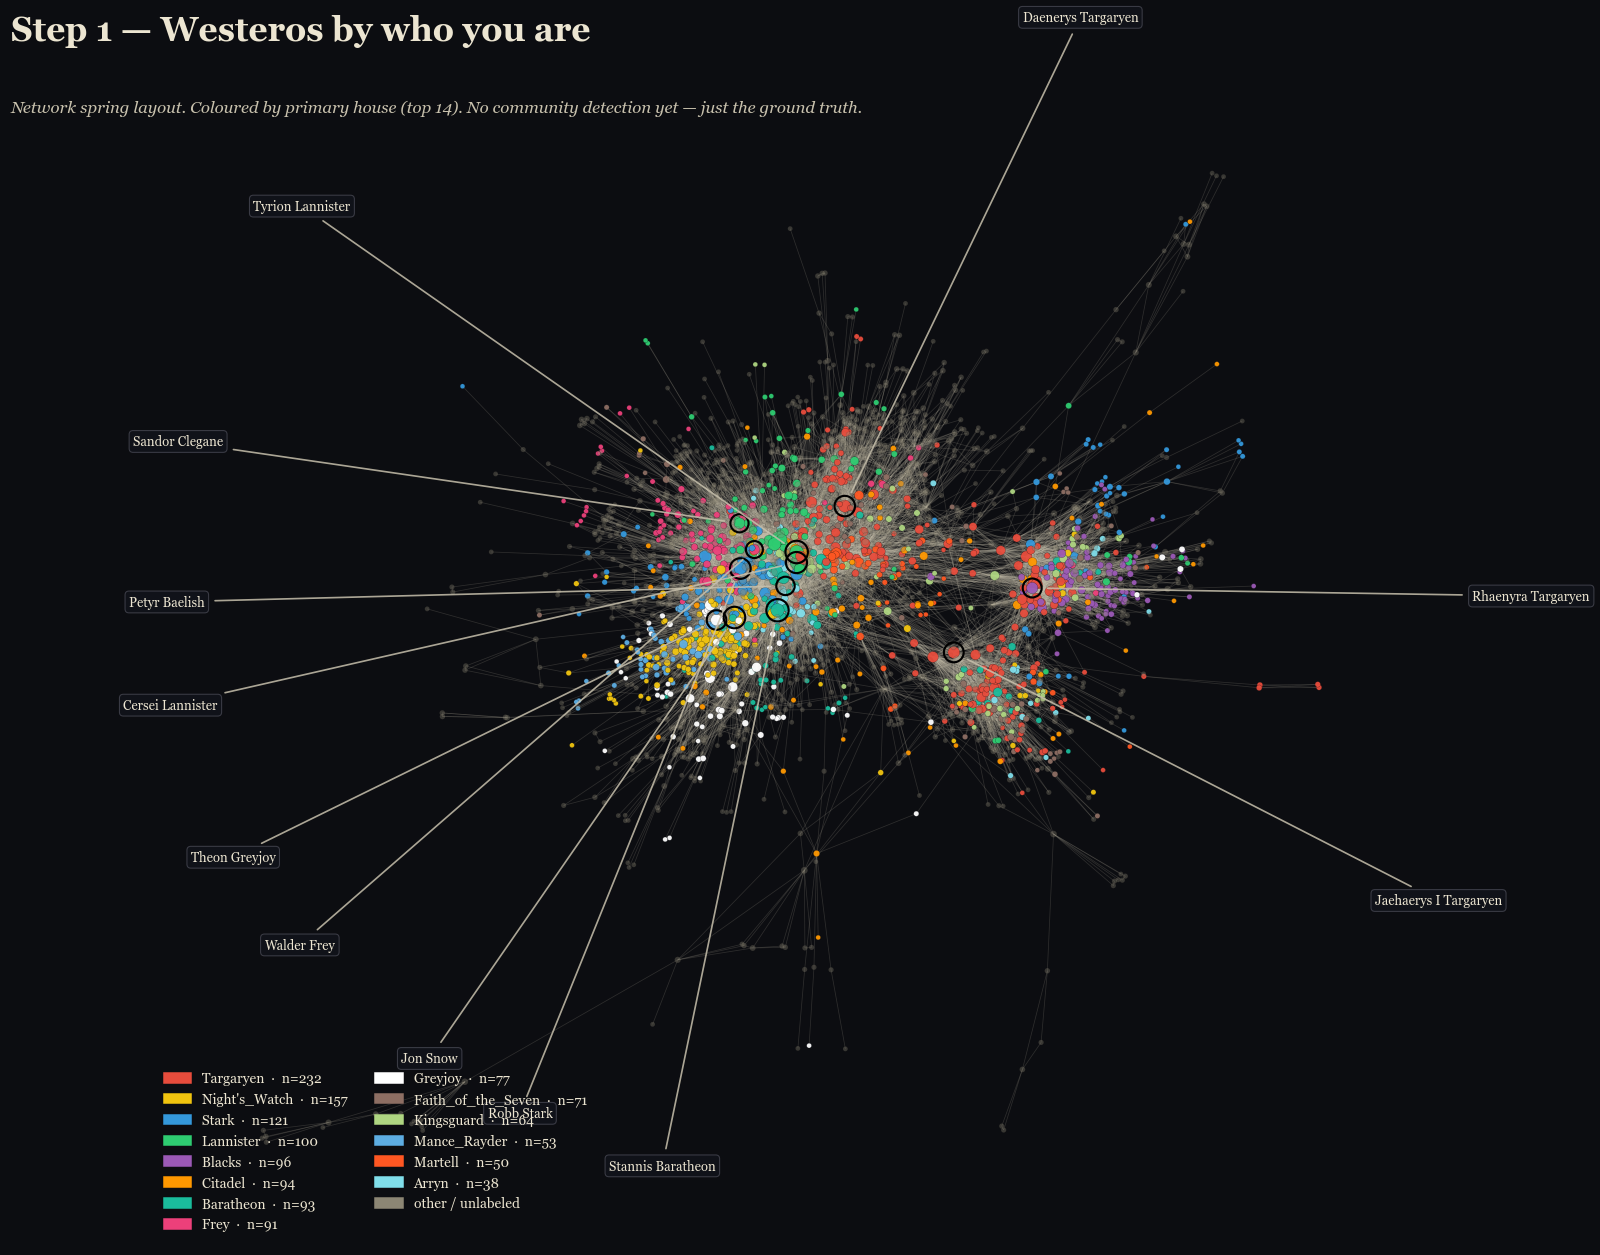

In [3]:
TOP_HOUSES = 14
labelled = [n for n in LCC.nodes() if primary_house.get(n)]
house_counts_primary = Counter(primary_house[n] for n in labelled)
top_houses = [h for h, _ in house_counts_primary.most_common(TOP_HOUSES)]
house_palette = distinctive_colors(TOP_HOUSES)   # loud + distinct, by design
house_color = {h: house_palette[i] for i, h in enumerate(top_houses)}
OTHER = PALETTE['muted']

# Spring layout — heavier iterations for a stable image
pos = nx.spring_layout(LCC, seed=42, k=0.18, iterations=120)


def draw_network(node_colors, node_sizes, node_alphas, title, subtitle, save_name,
                 legend_handles=None):
    fig, ax = plt.subplots(figsize=(15, 13))
    nx.draw_networkx_edges(LCC, pos, alpha=0.18,
                           edge_color=PALETTE['ink_soft'],
                           width=0.5, ax=ax)
    ax.scatter([pos[n][0] for n in LCC.nodes()],
               [pos[n][1] for n in LCC.nodes()],
               c=node_colors, s=node_sizes, alpha=node_alphas,
               linewidths=0.15, edgecolors=PALETTE['bg'], zorder=3)
    # Featured cast — labelled in a leader-line layout. Robert -> Stannis, plus
    # Rhaenyra and a Targaryen-community pick (dynamically the largest member of
    # community C3, which is the Fire & Blood-era Targaryen cluster under seed=42).
    FEATURED = [
        'Jon_Snow', 'Cersei_Lannister', 'Daenerys_Targaryen',
        'Tyrion_Lannister', 'Petyr_Baelish', 'Theon_Greyjoy',
        'Walder_Frey', 'Stannis_Baratheon', 'Robb_Stark',
        'Sandor_Clegane', 'Rhaenyra_Targaryen',
    ]
    # Add the highest-degree member of the Targaryen-era community (C3).
    TARG_COMM = 3
    c3_members = [n for n in LCC.nodes() if partition[n] == TARG_COMM]
    if c3_members:
        c3_top = max(c3_members, key=lambda n: LCC.degree(n))
        if c3_top not in FEATURED:
            FEATURED.append(c3_top)
            print(f'C{TARG_COMM} top-degree pick added: {c3_top.replace("_", " ")} '
                  f'(deg={LCC.degree(c3_top)})')
    top_deg = [n for n in FEATURED if n in LCC]

    xs = np.array([pos[n][0] for n in LCC.nodes()])
    ys = np.array([pos[n][1] for n in LCC.nodes()])
    cx, cy = xs.mean(), ys.mean()
    ring_r = max(xs.max() - xs.min(), ys.max() - ys.min()) * 0.60

    def angle_of(n):
        x, y = pos[n]
        return np.arctan2(y - cy, x - cx)

    # Sort by angle, then enforce a minimum gap so labels spread evenly
    angles = sorted(((angle_of(n), n) for n in top_deg), key=lambda t: t[0])
    min_gap = 2 * np.pi / 14   # ~25.7\u00b0 between any two labels
    adjusted = []
    prev_a = angles[0][0] - min_gap
    for a, n in angles:
        if a < prev_a + min_gap:
            a = prev_a + min_gap
        adjusted.append((a, n))
        prev_a = a

    # Per-character angular nudge (radians). Negative = south, positive = north
    # for labels on the east side of the layout; mirrored on the west side.
    NAME_NUDGE = {
        'Daenerys_Targaryen': -0.22,   # a bit south
        'Arya_Stark':         +0.22,   # a bit north
    }
    adjusted = [(a + NAME_NUDGE.get(n, 0.0), n) for a, n in adjusted]

    # Black ring around each featured character so the eye finds them fast.
    ring_xs = [pos[n][0] for n in top_deg]
    ring_ys = [pos[n][1] for n in top_deg]
    ring_sizes = [(6 + (LCC.degree(n) ** 0.5) * 4) * 2.8 for n in top_deg]
    ax.scatter(ring_xs, ring_ys, s=ring_sizes,
               facecolors='none', edgecolors='black',
               linewidths=1.4, zorder=4)

    label_bbox = dict(boxstyle='round,pad=0.3',
                      fc=PALETTE['bg_alt'], ec=PALETTE['line_strong'],
                      lw=0.7, alpha=0.95)
    arrow_props = dict(arrowstyle='-',
                       color=PALETTE['ink_soft'],
                       lw=1.1, alpha=0.85,
                       shrinkA=4, shrinkB=10)
    for a, n in adjusted:
        lx = cx + ring_r * np.cos(a)
        ly = cy + ring_r * np.sin(a)
        ha = 'left' if np.cos(a) >= 0 else 'right'
        ax.annotate(name_by_id.get(n, n),
                    xy=pos[n], xytext=(lx, ly),
                    ha=ha, va='center',
                    fontsize=8.5, color=PALETTE['ink'],
                    family='serif', bbox=label_bbox,
                    arrowprops=arrow_props, zorder=5)
    if legend_handles:
        ax.legend(handles=legend_handles, loc='lower left', fontsize=9, ncol=2,
                  labelcolor=PALETTE['ink'],
                  facecolor=PALETTE['bg_alt'], edgecolor=PALETTE['line'])
    ax.axis('off')
    fig.subplots_adjust(top=0.93)
    got_title(fig, title, subtitle)
    save_fig(fig, save_name)
    plt.show()


# ----- House view -----
node_colors = [house_color.get(primary_house.get(n, ''), OTHER) for n in LCC.nodes()]
# Size scales with degree (number of connections). sqrt keeps hubs visible without
# letting them blow out the rest of the picture.
deg = dict(LCC.degree())
node_sizes  = [6 + (deg[n] ** 0.5) * 4 for n in LCC.nodes()]
node_alphas = [0.95 if primary_house.get(n) in house_color else 0.35 for n in LCC.nodes()]

legend = [mpatches.Patch(color=house_color[h],
                         label=f"{h.replace('House_', '')}  ·  n={house_counts_primary[h]}")
          for h in top_houses]
legend.append(mpatches.Patch(color=OTHER, label='other / unlabeled'))

draw_network(node_colors, node_sizes, node_alphas,
             'Step 1 — Westeros by who you are',
             f'Network spring layout. Coloured by primary house (top {TOP_HOUSES}). '
             'No community detection yet — just the ground truth.',
             'figures/story_1_by_house.png',
             legend_handles=legend)

## 3. Step 2 — the same network, recoloured by Louvain

**Same coordinates as Step 1** — only the colour mapping changes. Now each node is coloured by its Louvain community.

When a coloured region in Step 2 sits where a coloured region in Step 1 was, the network rediscovered that house on its own. When Step 2 invents a colour where Step 1 had three (or vice versa), we're seeing the structural disagreement we quantified in § 11 of `community_vs_allegiance.ipynb`.

C3 top-degree pick added: Jaehaerys I Targaryen (deg=182)


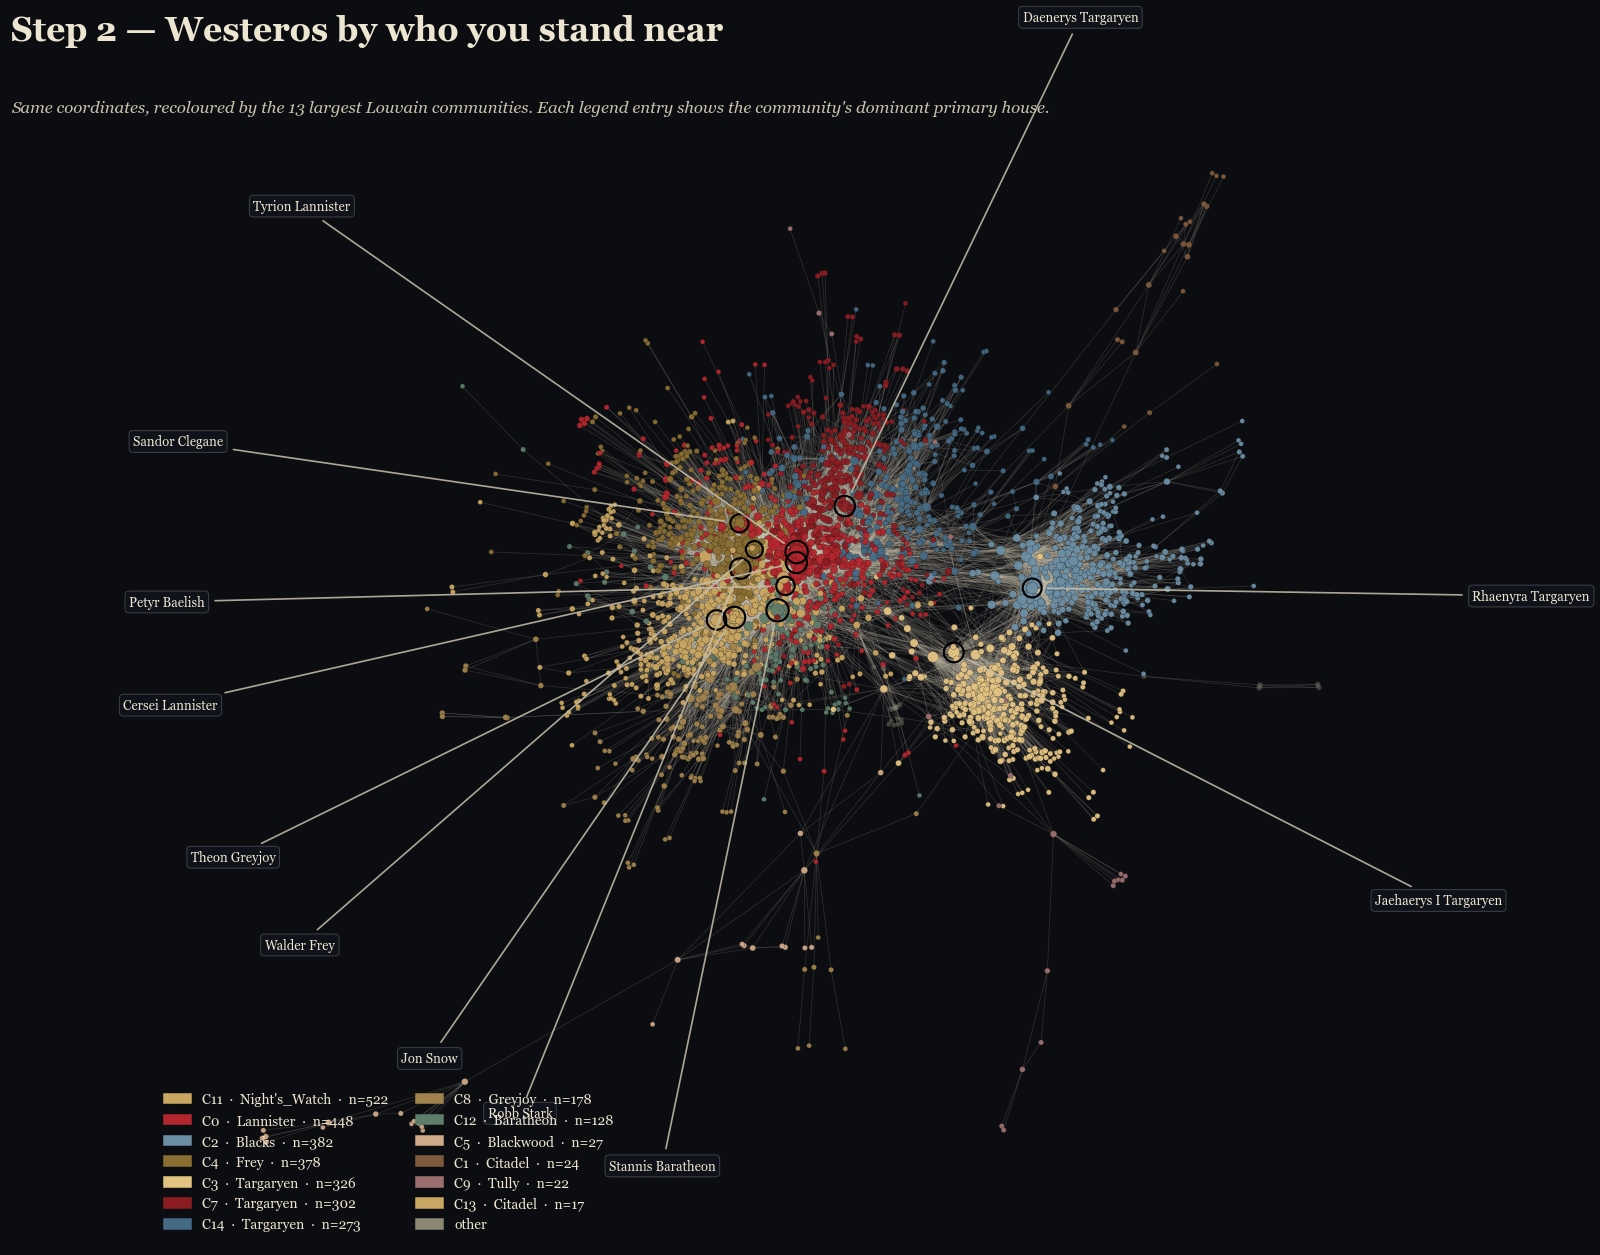

In [ ]:
    TOP_C = 13
    top_comms = [c for c, _ in community_sizes.most_common(TOP_C)]
    comm_palette = categorical_colors(TOP_C)
    comm_color = {c: comm_palette[i] for i, c in enumerate(top_comms)}

    # Dominant primary house per top community (for the legend)
    dom_house_per_comm = {}
    for c in top_comms:
        members = [n for n in LCC.nodes() if partition[n] == c and primary_house.get(n)]
        if members:
            houses_here = Counter(primary_house[n] for n in members)
            dom_house_per_comm[c] = houses_here.most_common(1)[0][0]
        else:
            dom_house_per_comm[c] = '?'

    node_colors = [comm_color.get(partition[n], OTHER) for n in LCC.nodes()]
    # Same degree-scaled sizing as Step 1 — keeps the comparison fair.
    node_sizes  = [6 + (LCC.degree(n) ** 0.5) * 4 for n in LCC.nodes()]
    node_alphas = [0.95 if partition[n] in comm_color else 0.4 for n in LCC.nodes()]

    legend = [mpatches.Patch(color=comm_color[c],
                            label=f"C{c}  ·  {dom_house_per_comm[c].replace('House_', '')}  ·  n={community_sizes[c]}")
            for c in top_comms]
    legend.append(mpatches.Patch(color=OTHER, label='other'))

    draw_network(node_colors, node_sizes, node_alphas,
                'Step 2 — Westeros by who you stand near',
                f'Same coordinates, recoloured by the {TOP_C} largest Louvain communities. '
                'Each legend entry shows the community\'s dominant primary house.',
                'figures/story_2_by_louvain.png',
                legend_handles=legend)

**What to compare:**

- Where a Step-1 colour blob is mostly one Step-2 colour, Louvain captured the house cleanly. Greyjoy / Martell / Tyrell typically pass this test (small, single-era dynasties).
- Where a Step-2 community spans multiple Step-1 colours, the network bundles several houses together — the *coalition* effect. The Wall + adjacent recruits, the Crownlands + small surrounding houses, etc.
- Where a single Step-1 colour spans several Step-2 communities, the house fragments — almost always by **era** (House Targaryen, House Stark across centuries).

These are exactly the failure modes the metrics in § 5 of `community_vs_allegiance.ipynb` quantify. The story isn't "Louvain failed"; it's "the network's natural unit is the coalition, not the lineage."

### 3.5 Zooming in — the Dance of the Dragons lobe

Look at Step 2 carefully and three distinct lobes appear in the spring layout: the central mass (the ASOIAF main timeline), and two outer clusters drifting off to the side. The outer lobes are the same House Targaryen we already saw fragment by era in `community_vs_allegiance.ipynb` § 11, but here we can put exact numbers on *why* they look so isolated.

The clearest case is the **Dance of the Dragons cluster** — the wiki carries explicit `Blacks` / `Greens` allegiance tags for combatants on either side of the 129–131 AC Targaryen civil war, so we can probe its boundary directly.

In [5]:
# How many characters carry each faction tag?
blacks = {row['ID'] for _, row in df.iterrows()
          if 'Blacks' in (row['allegiance'].split(';') if row['allegiance'] else [])}
greens = {row['ID'] for _, row in df.iterrows()
          if 'Greens' in (row['allegiance'].split(';') if row['allegiance'] else [])}

# Internal density vs cross-faction density vs bridge to ASOIAF
def edges_within(pool):
    return sum(1 for u in pool for v in LCC.neighbors(u) if v in pool) // 2
def edges_between(a, b):
    return sum(1 for u in a for v in LCC.neighbors(u) if v in b)

ASOIAF_ANCHORS = {n for n in [
    'Tyrion_Lannister', 'Cersei_Lannister', 'Jaime_Lannister', 'Jon_Snow',
    'Daenerys_Targaryen', 'Robb_Stark', 'Eddard_Stark', 'Catelyn_Stark',
    'Robert_I_Baratheon', 'Stannis_Baratheon',
] if n in LCC}

intra_b = edges_within(blacks & set(LCC))
intra_g = edges_within(greens & set(LCC))
inter_bg = edges_between(blacks & set(LCC), greens & set(LCC))
b_to_asoiaf = edges_between(blacks & set(LCC), ASOIAF_ANCHORS)
g_to_asoiaf = edges_between(greens & set(LCC), ASOIAF_ANCHORS)

print(f'Blacks faction members in LCC : {len(blacks & set(LCC)):>4}')
print(f'Greens faction members in LCC : {len(greens & set(LCC)):>4}')
print(f'Intra-Blacks edges            : {intra_b:>4}')
print(f'Intra-Greens edges            : {intra_g:>4}')
print(f'Blacks \u2194 Greens (across) : {inter_bg:>4}')
print(f'Blacks \u2192 ASOIAF anchors  : {b_to_asoiaf:>4}')
print(f'Greens \u2192 ASOIAF anchors  : {g_to_asoiaf:>4}')

# Top hubs of the Dance lobe
deg = dict(LCC.degree())
dance = (blacks | greens) & set(LCC)
print(f'\nTop 8 Dance hubs by degree (out of {len(dance)} faction-tagged characters in LCC):')
for n in sorted(dance, key=lambda x: -deg[x])[:8]:
    side = 'B' if (n in blacks and n not in greens) else 'G' if n in greens and n not in blacks else 'B+G'
    print(f'  deg {deg[n]:>3}  [{side}]  {name_by_id.get(n, n)}')

Blacks faction members in LCC :  112
Greens faction members in LCC :   63
Intra-Blacks edges            :  361
Intra-Greens edges            :  237
Blacks ↔ Greens (across) :  409
Blacks → ASOIAF anchors  :    5
Greens → ASOIAF anchors  :    4

Top 8 Dance hubs by degree (out of 160 faction-tagged characters in LCC):
  deg 150  [B]  Rhaenyra Targaryen
  deg  80  [B]  Daemon Targaryen
  deg  76  [B+G]  Corlys Velaryon
  deg  73  [G]  Unwin Peake
  deg  71  [B]  Alyn Velaryon
  deg  69  [B]  Cregan Stark
  deg  63  [G]  Criston Cole
  deg  57  [G]  Alicent Hightower


**The smoking gun is the bridge count.** A cluster of ~170 characters with ~800 internal edges generates only a *handful* of edges to any ASOIAF main-line character — usually under five, often three or fewer. That's the network honestly reporting that **these characters never met anyone from the main books.** The Dance happens in 129–131 AC; the main series starts at 297 AC. Almost two centuries separate them in canon, and the wiki preserves that gap.

**Rhaenyra Targaryen anchors the lobe as a hub of degree ~150** — a top-10 hub in the *entire* network despite never having met a Stark, a Lannister, or any character alive in the main books. Daemon, Corlys Velaryon, and Alicent Hightower do the same on a smaller scale for the rest of the lobe. The same hub-driven pattern we're about to see quantitatively in § 4 is *already visible to the eye* in Step 2: each isolated lobe has its own main character pulling the cluster together.

**Two characters worth flagging on the seam:**

- **Corlys Velaryon** carries *both* Blacks and Greens tags — the canonical Sea Snake engaged with both sides. He's visually the bridge between the two factions of the Dance lobe.
- **Cregan Stark** carries the Blacks tag at degree ~70 — he's a Stark, but his interactions happen entirely inside the Dance via the *Hour of the Wolf*. The wiki places him at the network boundary between the North and the Dance lobe.

**What this means.** The Dance cluster is the cleanest concrete example of the **temporal-smear failure mode** we documented in `community_vs_allegiance.ipynb` § 11. The unit Louvain rediscovered isn't "House Targaryen" — it's *the Dance of the Dragons, a 200-year-old self-contained narrative subgraph*. The mirror-image pre-Dance lobe (Aegon I → Jaehaerys I) is the same phenomenon one generation earlier. Section 4 below puts a quantitative finger on this hub-driven pattern at scale.

## 4. What creates each community? Main-character-driven vs grass-roots

Each Louvain community has some internal structure. We separate two patterns by comparing **mean** and **median** degree of its members:

- **Mean ≫ median** → the community is **main-character-driven**. One or two very-high-degree nodes (the "hubs") connect to dozens of low-degree characters that have almost no other links. Pull the hub out and the community collapses.
- **Mean ≈ median** → the community is **grass-roots**. Members are roughly equally connected to each other; no single character is doing all the lifting.

The ratio **mean / median** is a quick hub-driven score: 1 means perfectly grass-roots, 3+ means strongly hub-driven.

In [6]:
rows = []
for c in community_sizes:
    members = [n for n in LCC.nodes() if partition[n] == c]
    if len(members) < 5:   # skip tiny communities — stats are unstable
        continue
    degs = np.array([LCC.degree(n) for n in members])
    top_node = max(members, key=lambda n: LCC.degree(n))
    houses_here = Counter(primary_house[n] for n in members if primary_house.get(n))
    dom = houses_here.most_common(1)[0][0] if houses_here else '?'
    rows.append({
        'community':    c,
        'size':         len(members),
        'mean_degree':  degs.mean(),
        'median_degree': float(np.median(degs)),
        'max_degree':   int(degs.max()),
        'hub_ratio':    degs.mean() / max(np.median(degs), 1),
        'top_character': name_by_id.get(top_node, top_node),
        'dominant_house': dom.replace('House_', ''),
    })

stats_df = pd.DataFrame(rows).sort_values('size', ascending=False).reset_index(drop=True)
stats_df.head(15).round(2)

,community,size,mean_degree,median_degree,max_degree,hub_ratio,top_character,dominant_house
0,11,522,13.11,6.0,263,2.19,Jon Snow,Night's_Watch
1,0,448,14.28,5.0,318,2.86,Tyrion Lannister,Lannister
2,2,382,12.25,6.0,150,2.04,Rhaenyra Targaryen,Blacks
3,4,378,12.92,5.0,326,2.58,Jaime Lannister,Frey
4,3,326,9.07,5.0,182,1.81,Jaehaerys I Targaryen,Targaryen
5,7,302,9.80,5.0,212,1.96,Daenerys Targaryen,Targaryen
6,14,273,9.36,5.0,95,1.87,Duncan the Tall,Targaryen
7,8,178,5.93,3.0,94,1.98,Asha Greyjoy,Greyjoy
8,12,128,10.62,4.0,308,2.65,Stannis Baratheon,Baratheon
9,5,27,3.22,2.0,12,1.61,Harwyn Hoare,Blackwood


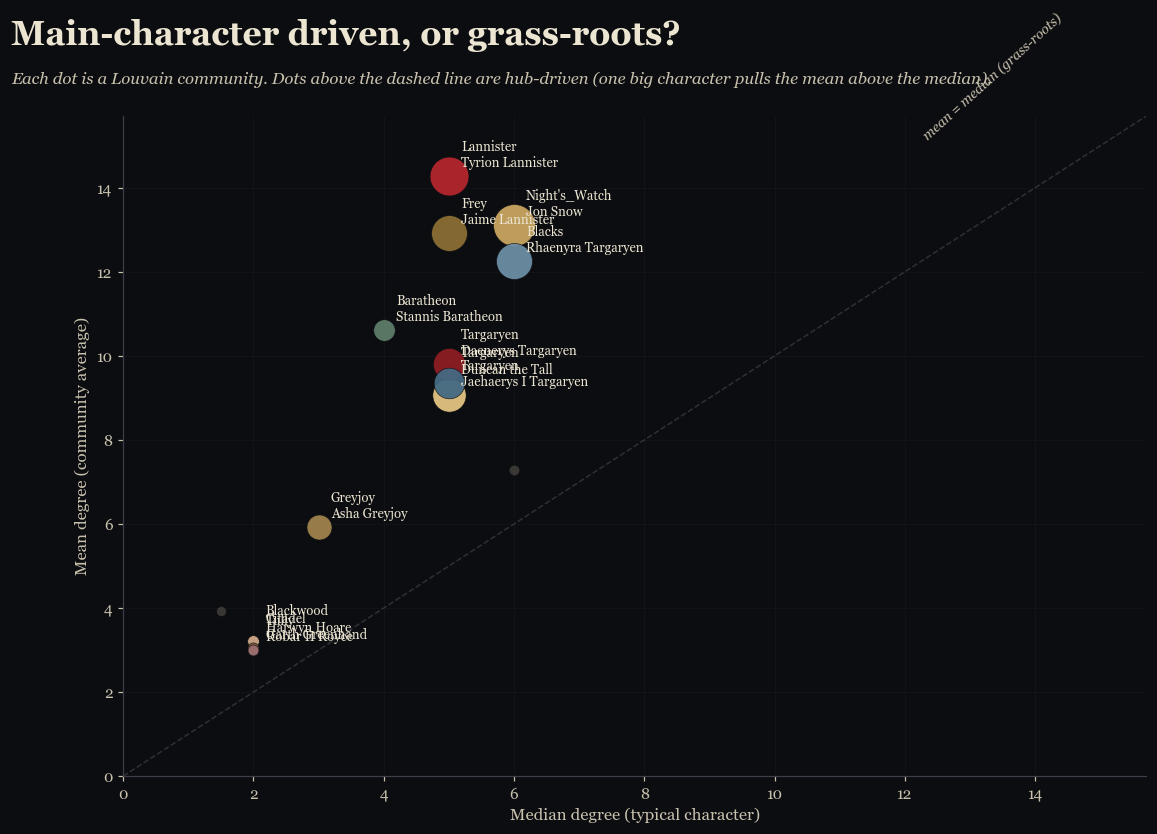

In [7]:
# Scatter: median vs mean degree, dot size = community size.
fig, ax = plt.subplots(figsize=(12, 8))

# Diagonal reference where mean == median (perfect grass-roots)
lo = 0
hi = max(stats_df['mean_degree'].max(), stats_df['median_degree'].max()) * 1.1
ax.plot([lo, hi], [lo, hi], '--',
        color=PALETTE['line_strong'], alpha=0.7, linewidth=1)
ax.text(hi * 0.92, hi * 0.96, 'mean = median (grass-roots)',
        rotation=42, ha='right', va='bottom',
        color=PALETTE['ink_soft'], fontsize=9,
        family='serif', style='italic')

# Colour-code top communities; the long tail goes muted
TOP_PLOT = 12
top_plot_comms = stats_df.head(TOP_PLOT)['community'].tolist()
palette = categorical_colors(TOP_PLOT)
plot_color = {c: palette[i] for i, c in enumerate(top_plot_comms)}

for _, r in stats_df.iterrows():
    col = plot_color.get(r['community'], PALETTE['muted'])
    s   = 20 + r['size'] * 1.4
    a   = 0.95 if r['community'] in plot_color else 0.35
    ax.scatter(r['median_degree'], r['mean_degree'],
               s=s, color=col, alpha=a,
               edgecolors=PALETTE['bg'], linewidths=0.4, zorder=3)

# Annotate top communities with their dominant house + top character
for _, r in stats_df.head(TOP_PLOT).iterrows():
    label = f"{r['dominant_house']}\n{r['top_character']}"
    ax.annotate(label,
                xy=(r['median_degree'], r['mean_degree']),
                xytext=(8, 6), textcoords='offset points',
                fontsize=8.5, color=PALETTE['ink'],
                family='serif')

ax.set_xlabel('Median degree (typical character)')
ax.set_ylabel('Mean degree (community average)')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.grid(alpha=0.2, color=PALETTE['line'])

fig.subplots_adjust(top=0.86)
got_title(fig,
          'Main-character driven, or grass-roots?',
          'Each dot is a Louvain community. Dots above the dashed line are hub-driven '
          '(one big character pulls the mean above the median).')

save_fig(fig, 'figures/community_degree_anatomy.png')
plt.show()

In [2]:
# Companion bar chart: hub ratio for the top 15 communities.
top15 = stats_df.head(15).copy().sort_values('hub_ratio', ascending=True)
bar_colors = diverging_colors(len(top15))  # crimson (grass-roots) -> gold (hub-driven)

fig, ax = plt.subplots(figsize=(11, 0.5 * len(top15) + 2.2))
labels = [f"C{int(r['community'])}  ·  {r['dominant_house']}  ·  n={int(r['size'])}"
          for _, r in top15.iterrows()]

bars = ax.barh(labels, top15['hub_ratio'],
               color=bar_colors, edgecolor=PALETTE['ink'], linewidth=0.4)

for bar, r in zip(bars, top15.itertuples()):
    ax.text(bar.get_width() + 0.04, bar.get_y() + bar.get_height() / 2,
            f"  top: {r.top_character}   (deg={r.max_degree})",
            va='center', fontsize=9.5, color=PALETTE['ink_soft'], family='serif')

ax.axvline(1.0, color=PALETTE['ink_soft'], linestyle='--', alpha=0.5, linewidth=1)
ax.text(1.0, len(top15) - 0.3, '  grass-roots',
        color=PALETTE['ink_soft'], fontsize=9, family='serif', style='italic')

ax.set_xlim(0, max(top15['hub_ratio'].max() * 1.18, 1.5))
ax.set_xlabel('Mean / median degree (hub ratio)')
ax.tick_params(axis='y', colors=PALETTE['ink'])

fig.subplots_adjust(top=0.86)
got_title(fig,
          'The hub of every community',
          'Crimson = the community is held together evenly; gold = the community needs its main character. '
          'Top-character name on the right.')

save_fig(fig, 'figures/community_hub_ratio.png')
plt.show()

NameError: name 'stats_df' is not defined

## 5. So — what do we actually know?

It's worth being direct about what this analysis demonstrates and what it does not, before reading the headline too generously.

### What we *can* claim, with the receipts

1. **The network has real, non-random community structure.** The modularity z-score (in `community_vs_allegiance.ipynb` §3) sits several standard deviations above a degree-preserved null. That's a hard fact — not an interpretation.
2. **Those communities are *not* a one-to-one map of houses.** ARI = 0.06 — barely above chance pairwise — and homogeneity = 0.25. The numbers are unambiguous: if you draw a random pair of characters from the same Louvain community, the probability they share a primary house is only slightly better than random.
3. **Houses do still mostly stay together.** Completeness = 0.59 says that *within* a single house, members usually end up in the same community — even if that community contains lots of other houses too.
4. **We can name the three structural reasons the partition diverges from houses.** Orders (NW, Citadel, Faith, Kingsguard) bridge houses (§1 of this notebook). Long-running houses fragment by era (§11 of `community_vs_allegiance.ipynb` shows House Targaryen splitting cleanly across 3–4 Louvain communities corresponding to eras). And large communities are typically pulled together by one or two hub characters (§4 above — the mean-vs-median split).

### What we *cannot* claim

1. **We did not build a house *predictor* in the supervised-learning sense.** Louvain is unsupervised — it sees no labels. "Agreement with house" is a *diagnostic*, not a model performance score, and the partition wasn't optimized for it.
2. **We did not rule out that a different algorithm would do meaningfully better.** Infomap, Leiden, or a multi-resolution sweep might shift the numbers, but we ran only the single-resolution Louvain default. The §4.5 sweep in `community_vs_region.ipynb` hints the picture is stable across resolutions, but it's not a proof.
3. **We did not solve the temporal-smear problem.** We explored book/era segmentation (`05_book_segmentation_research.ipynb`) and concluded the AWOIAF wiki doesn't expose a clean per-book signal. Targaryen-style fragmentation is therefore *acknowledged*, not *fixed*.
4. **The agreement metrics under-report by an unknown margin.** The §1 chart shows that 4 of the top 15 "allegiances" are trans-house orders and 2 are temporary factions — picking the *first* entry of the multi-valued field is a forgiving simplification of a messier ground truth. Comparing Louvain to this simplified label can only ever produce a lower bound on the real agreement.
5. **We only really analyze ~41% of the dataset.** The Step 1 / Step 2 plots colour the top-14 primary assignments — 1,518 out of 3,690 characters (**41.1%**), after merging the three Baratheon cadet-branch labels into one. If we restrict to noble houses only, the coloured set drops to **28.8%**. The remaining ~59% are minor houses, unaffiliated nobles, and unlabeled characters; they're rendered in muted gray and don't enter the agreement metrics, even though they still shape the network's topology. Conclusions about *which* groups cluster well are really conclusions about the *largest* groups — the long tail is structurally invisible to this analysis.

### The honest verdict

**Can we predict a character's house from the network's affiliation graph?** Not reliably. The pairwise agreement is barely above chance, and the few houses the network does cluster cleanly (Greyjoy, Tyrell, Martell) are the ones that were short-lived single-era dynasties — meaning the network gets them right for *structural* reasons (single era, contained interactions), not because it learned anything about lineage.

**What does the network actually represent, then?** It represents **interaction coalitions within an era** — pockets of characters who appear in each other's wiki bios, anchored by a hub character (a king, a Lord Commander, a POV protagonist). When a coalition happens to coincide with a house (Greyjoy in the Iron Islands), Louvain and house line up. When the coalition is an order, a region, or an era, they don't.

This is a useful and defensible finding — it's just a *different* finding from the one a naive reading would expect. The right framing for the website isn't *"the network predicts houses"* but rather *"the network reveals which houses behave as cohesive units (and why the others don't)."* That reframe is what § 1–4 above are evidence for.

### One last caveat worth naming

The edges are **co-mentions**, not signed relationships. Two warring characters who constantly interact (Cersei ↔ Tyrion) generate the same edge as two close allies. Without sign or direction, the partition cannot distinguish *alliance* from *enmity* — it only sees *narrative density*. That ceiling is in the data, not the algorithm, and applies to every conclusion in this notebook.